In [16]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
Auto = pd.read_csv("..\..\Datasets\Auto.csv", na_values=["?"])
Auto.head()


<>:8: SyntaxWarning: invalid escape sequence '\.'
<>:8: SyntaxWarning: invalid escape sequence '\.'
C:\Users\olive\AppData\Local\Temp\ipykernel_21268\2372866086.py:8: SyntaxWarning: invalid escape sequence '\.'
  Auto = pd.read_csv("..\..\Datasets\Auto.csv", na_values=["?"])


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [23]:
Auto = Auto.dropna()
y = Auto["mpg"]
design = MS(['horsepower']).fit(Auto)
X =  design.transform(Auto)

modelo = sm.OLS(y, X)
resultados = modelo.fit()
summarize(resultados)


,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


In [37]:
df = pd.DataFrame({'horsepower':[98]})
predicoes = resultados.get_prediction(design.transform(df))
print('Predição de mpg para horsepower de 98:', predicoes.predicted_mean[0])

Predição de mpg para horsepower de 98: 24.467077152512427


In [40]:
print('Intervalo de confiança:', predicoes.conf_int(alpha=0.05))
print('Intervalo de predição:', predicoes.conf_int(obs=True, alpha=0.05))

Intervalo de confiança: [[23.97307896 24.96107534]]
Intervalo de predição: [[14.80939607 34.12475823]]


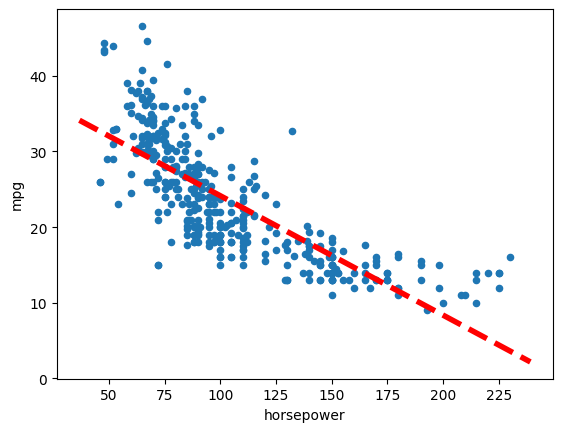

In [35]:
def abline(ax, b, m, *args, **kwargs):
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b ]
    ax.plot(xlim, ylim, *args, **kwargs)

ax = Auto.plot.scatter('horsepower', 'mpg')

abline(ax,
       resultados.params['intercept'],
       resultados.params['horsepower'],
       c='r',
       ls='--',
       linewidth=4)

In [46]:
print('RSS:', resultados.ssr)
print('RSE:', np.sqrt(resultados.scale))
print('σ²:', resultados.scale)
print('R2:', resultados.rsquared)

RSS: 9385.91587193242
RSE: 4.90575691954594
σ²: 24.066450953672874
R2: 0.6059482578894348
